In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from tqdm.auto import tqdm
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from multiprocessing import Pool


import torch
import torch.nn as nn
import torch.nn.functional as F
import gc
import random
from cosine_annealing_warmup import CosineAnnealingWarmupRestarts as CAWR
from sklearn.linear_model import LinearRegression
from multiprocessing import Pool

In [3]:
def get_signal(signal_path,L_CUT = 0, U_CUT = 0):

    f = open(signal_path, "r")
    data = f.readlines()
    f.close()
    ################################################################################################
    
    ################################################################################################
    y = np.array(list(map(lambda x: abs(float(x.split("\t")[-1].split("\n")[0])), data)), dtype=float)
    x = np.array(list(map(lambda x: float(x.split("\t")[0].split("\n")[0]), data)), dtype=float)
    max_x = x.max()
    idx = (x>L_CUT) * (x<=(max_x-U_CUT))
    
    x = x[idx]
    y = y[idx]
    return x,y


In [4]:
DATA_PATH = "../CorrelatorStudy/Bdata/ext2/"


In [5]:
signal_list  = ["B0_st",
                "cas_q_hl_32",
                "cas_c_hh_12",
                "lambcs_bc_32"]

marker_list = ["*","*","*","*"]

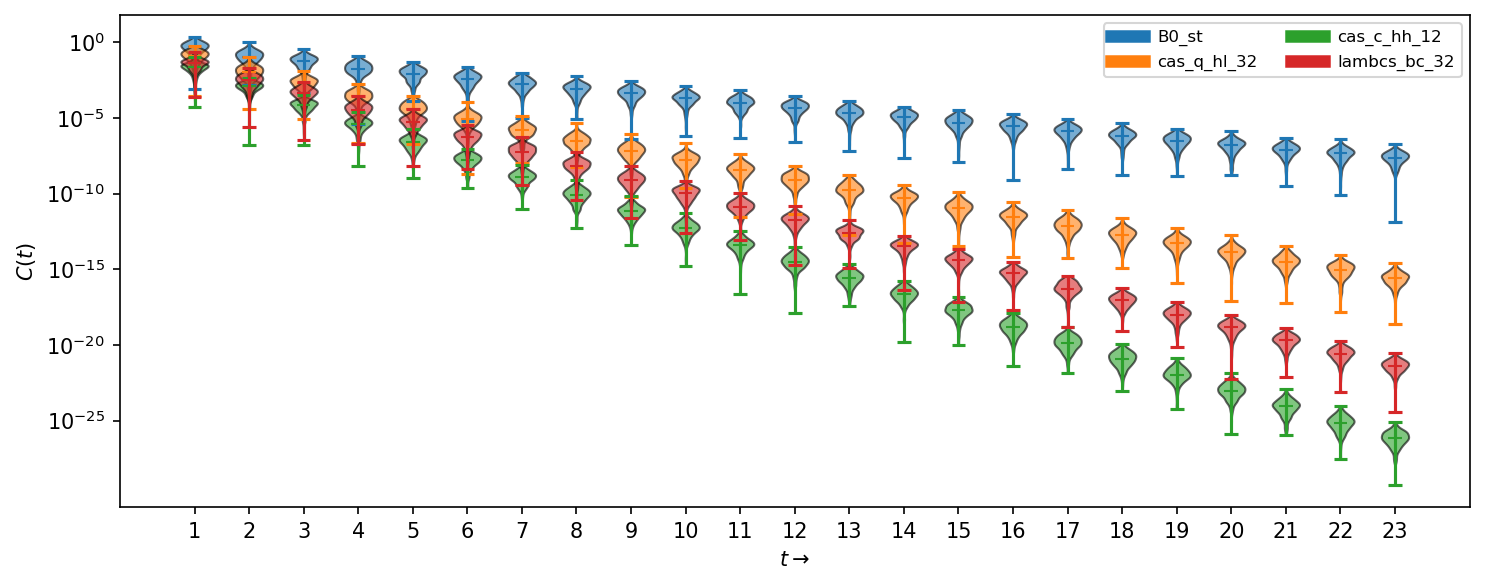

In [7]:
plt.figure(figsize=(10,4), dpi=150)

data = {}
handles = []
for i,signal in enumerate(signal_list):
    x, y = get_signal(signal_path=f"{DATA_PATH}/{signal}", L_CUT=0, U_CUT=0)
    
    UNIQUE_X = np.unique(x)

    set_y = []
    for x_val in UNIQUE_X:
        y_val = y[x == x_val]
        set_y.append(np.log10(y_val))
    parts = plt.violinplot(
        set_y,
        showmedians=True,
        showextrema=True,
        bw_method='scott',
    )
    color = f"C{i}"
    for b in parts["bodies"]:
        b.set_facecolor(color); b.set_edgecolor("black"); b.set_alpha(0.6)
    parts["cmedians"].set_linewidth(1)
    handles.append(plt.Line2D([0],[0], color=color, lw=6, label=signal))


plt.xlabel(r"$t \rightarrow$")
plt.ylabel(r"$C(t)$")
plt.xticks(UNIQUE_X)


y_ticks = -1*np.arange(0,30,5)
plt.yticks(y_ticks,[rf"$10^{{{int(i)}}}$" for i in y_ticks])

plt.legend(handles=handles, ncol=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig("./store/eda1.png")
plt.show()


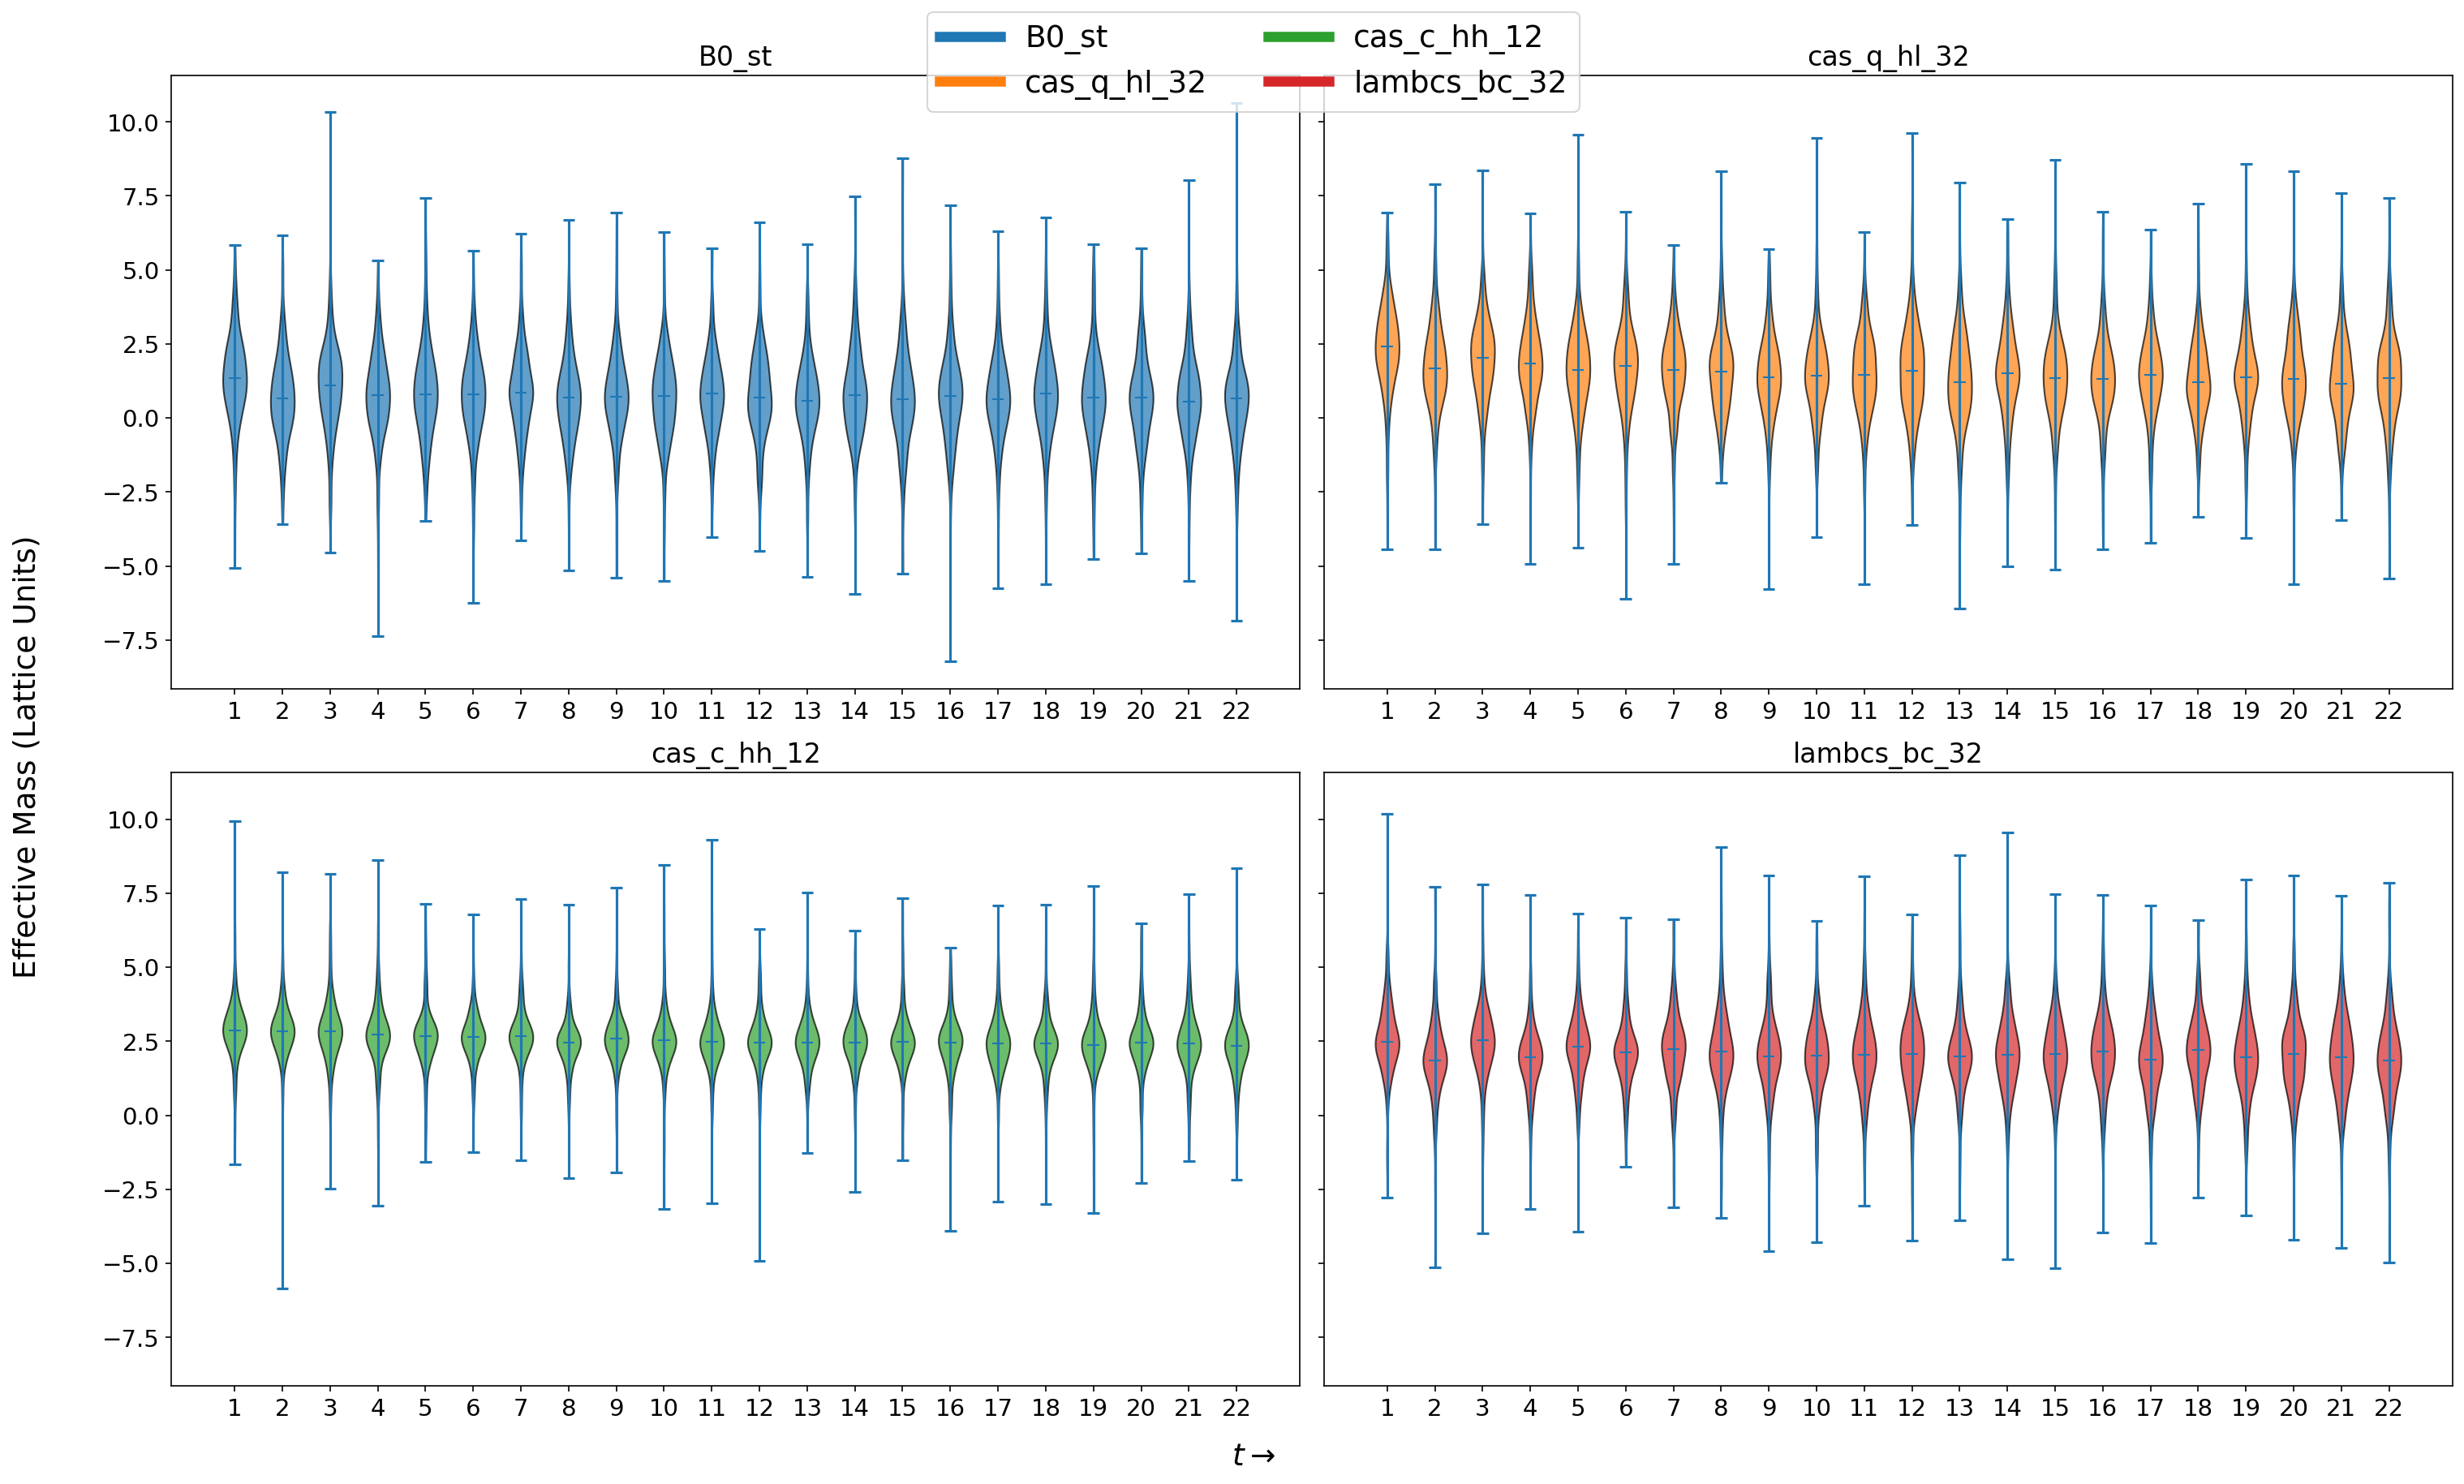

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20,12), dpi=150, sharey=True)
handles = []

for i, (ax, signal) in enumerate(zip(axes.flat, signal_list)):
    x, y = get_signal(signal_path=f"{DATA_PATH}/{signal}", L_CUT=0, U_CUT=0)
    
    nbins = np.unique(x).shape[0]
    x = np.reshape(x, [-1, nbins])
    y = np.reshape(y, [-1, nbins])
    meff = np.log(y[:, :-1] / y[:, 1:])

    centers = x[0, :-1]

    parts = ax.violinplot(
        meff,
        positions=centers,
        showmedians=True,
        showextrema=True,
        bw_method='scott',
    )
    color = f"C{i}"
    for b in parts["bodies"]:
        b.set_facecolor(color); b.set_edgecolor("black"); b.set_alpha(0.7)
    parts["cmedians"].set_linewidth(1)
    handles.append(plt.Line2D([0],[0], color=color, lw=6, label=signal))

    ax.set_title(signal, fontsize=16)
    ax.set_xticks(centers)

for ax in axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
    # ax.grid(True)

fig.supxlabel(r"$t \rightarrow$", fontsize=18)
fig.supylabel("Effective Mass (Lattice Units)",  x=-0.01, fontsize=18)
fig.legend(handles=handles, ncol=2, fontsize=18, frameon=True,
           loc="upper center", bbox_to_anchor=(0.5, 1.02))

plt.tight_layout()
plt.savefig("./store/eda2.png")
plt.show()

## Looking at the Central Tendencies

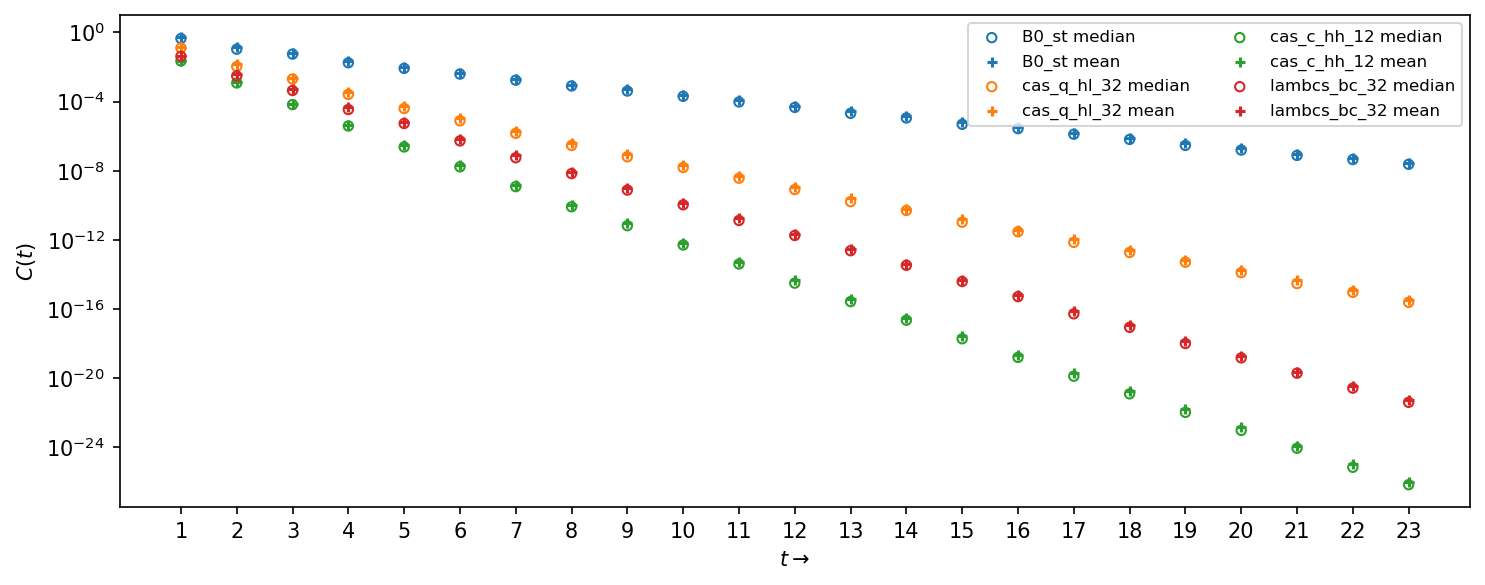

In [9]:
plt.figure(figsize=(10,4), dpi=150)

data = {}
handles = []
for i,signal in enumerate(signal_list):
    x, y = get_signal(signal_path=f"{DATA_PATH}/{signal}", L_CUT=0, U_CUT=0)
    
    UNIQUE_X = np.unique(x)

    mean_y = []
    median_y = []
    
    for x_val in UNIQUE_X:
        y_val = y[x == x_val]
        mean_y.append(np.mean(y_val))
        median_y.append(np.median(y_val))
        

    color = f"C{i}"
    p1 = plt.scatter(UNIQUE_X, median_y, s=20, marker='o',
                     facecolors='none', edgecolors=color,
                     label=f"{signal} median")
    p2 = plt.scatter(UNIQUE_X, mean_y, s=20, marker='+',
                     color=color, label=f"{signal} mean")
    handles.extend([p1, p2])

plt.yscale("log")
plt.xlabel(r"$t \rightarrow$")
plt.ylabel(r"$C(t)$")

# use ticks from all signals
xticks_sorted = np.sort(UNIQUE_X)
plt.xticks(xticks_sorted)

plt.legend(handles=handles, ncol=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig("./store/eda3.png")
plt.show()

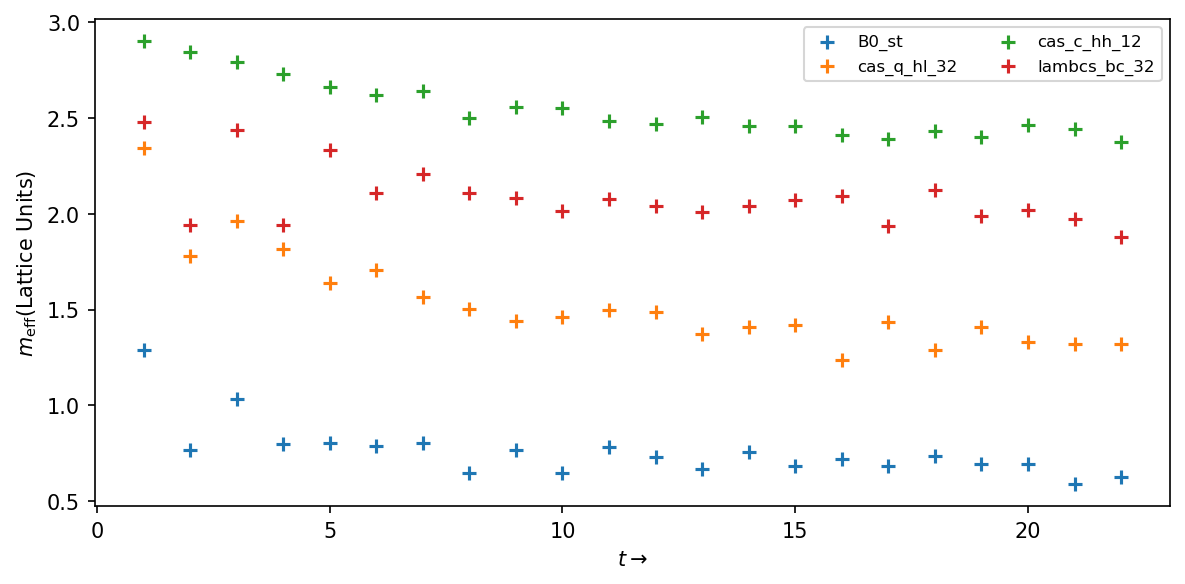

In [10]:
plt.figure(figsize=(8,4), dpi=150)

xticks_all = set()

for i, signal in enumerate(signal_list):
    x, y = get_signal(signal_path=f"{DATA_PATH}/{signal}", L_CUT=0, U_CUT=0)
    x = np.asarray(x)
    y = np.asarray(y)

    UNIQUE_X = np.unique(x)
    mean_y = np.array([y[x == xv].mean() for xv in UNIQUE_X])

    x_eff = UNIQUE_X[:-1]
    mass_eff_mean = np.log(mean_y[:-1] / mean_y[1:])

    color = f"C{i}"
    plt.scatter(x_eff, mass_eff_mean, s=40, marker='+',
                color=color, label=f"{signal}")

plt.xlabel(r"$t \rightarrow$")
plt.ylabel(r"$m_\mathrm{eff}$(Lattice Units)")

if xticks_all:
    plt.xticks(np.sort(list(xticks_all)))

plt.legend(ncol=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig("./store/eda4.png")
plt.show()
